<a href="https://colab.research.google.com/github/sofianna-e/DeliveriesEKPA/blob/main/IDS_to_IPS_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Εισαγωγή βιβλιοθηκών
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# Παράμετροι
epochs = 40
batch_size = 64
nclass = 3  # Normal, Anomaly, Attack

In [3]:
# Φόρτωση Dataset
def load_dataset():
    url = 'https://raw.githubusercontent.com/kdemertzis/EKPA/refs/heads/main/Data/pcap_data.csv'
    data = pd.read_csv(url).to_numpy()

    X = data[:, :-1].astype('float32')
    y = data[:, -1].astype('int32')

    # Ανακάτεμα και Διαχωρισμός
    np.random.shuffle(data)
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=2/3, stratify=y_temp, random_state=42)

    # Min-max normalization
    dmin = X_train.min(axis=0)
    dmax = X_train.max(axis=0)
    X_train = (X_train - dmin) / (dmax - dmin)
    X_val = (X_val - dmin) / (dmax - dmin)
    X_test = (X_test - dmin) / (dmax - dmin)

    return X_train, y_train, X_val, y_val, X_test, y_test

In [4]:
# Φόρτωση δεδομένων
X_train, y_train_raw, X_val, y_val_raw, X_test, y_test_raw = load_dataset()

In [5]:
# Μετατροπή labels σε one-hot
y_train = to_categorical(y_train_raw, nclass)
y_val   = to_categorical(y_val_raw, nclass)
y_test  = to_categorical(y_test_raw, nclass)

In [6]:
# Υπολογισμός κλάσεων βαρών
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_raw),
    y=y_train_raw
)
class_weights = dict(enumerate(class_weights))

In [7]:
# Δημιουργία μοντέλου
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(nclass, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,003 (187.51 KB)

 Trainable params: 48,003 (187.51 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Εκπαίδευση
early_stop = EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min')
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    class_weight=class_weights,
    shuffle=True,
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/40
164/164 - 2s - 14ms/step - accuracy: 0.7350 - loss: 0.7010 - val_accuracy: 0.8250 - val_loss: 0.5382
Epoch 2/40
164/164 - 1s - 3ms/step - accuracy: 0.8297 - loss: 0.5089 - val_accuracy: 0.8544 - val_loss: 0.4703
Epoch 3/40
164/164 - 1s - 3ms/step - accuracy: 0.8527 - loss: 0.4630 - val_accuracy: 0.8724 - val_loss: 0.4390
Epoch 4/40
164/164 - 1s - 3ms/step - accuracy: 0.8729 - loss: 0.4223 - val_accuracy: 0.8945 - val_loss: 0.3874
Epoch 5/40
164/164 - 1s - 3ms/step - accuracy: 0.8855 - loss: 0.3996 - val_accuracy: 0.8925 - val_loss: 0.3903
Epoch 6/40
164/164 - 1s - 3ms/step - accuracy: 0.8939 - loss: 0.3855 - val_accuracy: 0.8965 - val_loss: 0.3694
Epoch 7/40
164/164 - 1s - 4ms/step - accuracy: 0.8968 - loss: 0.3745 - val_accuracy: 0.9178 - val_loss: 0.3503
Epoch 8/40
164/164 - 1s - 4ms/step - accuracy: 0.9000 - loss: 0.3684 - val_accuracy: 0.9112 - val_loss: 0.3503
Epoch 9/40
164/164 - 1s - 4ms/step - accuracy: 0.9006 - loss: 0.3641 - val_accuracy: 0.9071 - val_loss: 0.3554


In [9]:
# Αξιολόγηση
pred = model.predict(X_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [10]:
# Kαθορισμός κατωφλίου (threshold) για την διακοπή διακτυακής κίνησης
blocking_threshold = 0.9

In [11]:
# Aποκλεισμός δικτυακής κυκλοφορίας εάν η προβλεπόμενη πιθανότητα υπερβαίνει το καθορισμένο όριο
blocked_indices = np.where(pred[:, 2] > blocking_threshold)[0]
if len(blocked_indices) > 0:
    print(f"Blocking {len(blocked_indices)} malicious traffic instances.")

pred_labels = pred.argmax(axis=-1)
y_test_labels = y_test.argmax(axis=-1)

cm = confusion_matrix(y_test_raw, pred_labels)
print("Confusion Matrix:")
print(cm)

classes = ['Normal', 'Anomaly', 'Attack']
print("\nAccuracy per class:")
for i, name in enumerate(classes):
    acc = cm[i,i]/np.sum(cm[i,:])
    print(f"{name:<8}: {acc:.4f}")

Blocking 672 malicious traffic instances.
Confusion Matrix:
[[884  71  46]
 [ 41 926  36]
 [ 50  31 909]]

Accuracy per class:
Normal  : 0.8831
Anomaly : 0.9232
Attack  : 0.9182


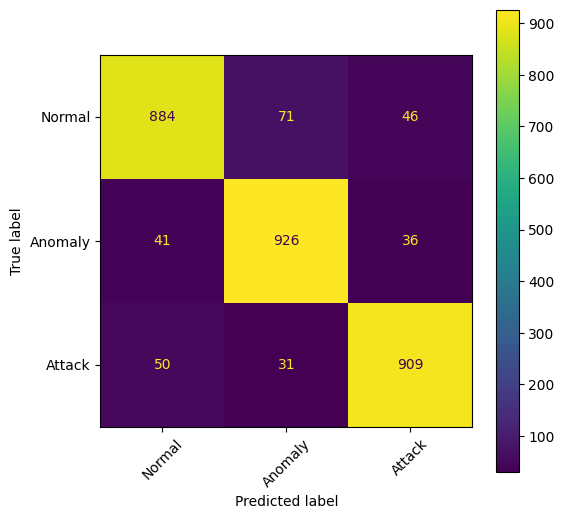

In [12]:
# Confusion Matrix
cmo = ConfusionMatrixDisplay(cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(6,6))
cmo.plot(ax=ax, xticks_rotation=45)
plt.show()

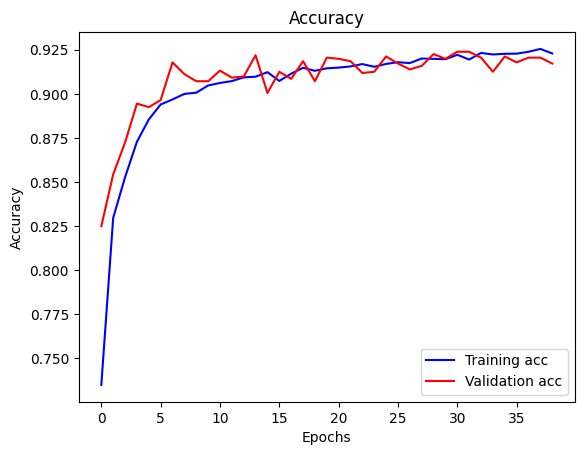

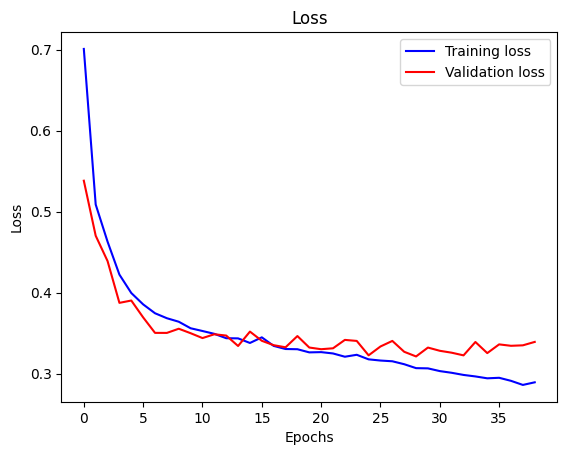

In [13]:
# Accuracy & Loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure()
plt.plot(epochs_range, acc, 'b', label='Training acc')
plt.plot(epochs_range, val_acc, 'r', label='Validation acc')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.figure()
plt.plot(epochs_range, loss, 'b', label='Training loss')
plt.plot(epochs_range, val_loss, 'r', label='Validation loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [14]:
from sklearn.metrics import classification_report, accuracy_score

accuracy = accuracy_score(y_test_raw, pred_labels)
classification_rep = classification_report(y_test_raw, pred_labels)

print(f"Final Test Accuracy: {accuracy}")
print("Classification Report:")
print(classification_rep)

Final Test Accuracy: 0.9081496325985304
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      1001
           1       0.90      0.92      0.91      1003
           2       0.92      0.92      0.92       990

    accuracy                           0.91      2994
   macro avg       0.91      0.91      0.91      2994
weighted avg       0.91      0.91      0.91      2994

